# DeFi-TVL-Momentum — a quantitative teardown 🔬
### TVL-growth cross-sectional sort · one-sample *t* · label-shuffle placebo · month-clustered slope · robustness grid · costs & borrow · seed-robust synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We rank DeFi protocols by trailing TVL growth, long the top / short the bottom, and test whether the forward token-return spread is reliably positive.

> ⚠️ **Not investment advice.** This is a **synthetic-only** study: no survivorship-free, point-in-time per-protocol TVL x token-return panel is reachable on a free, no-key stack, so `HAVE_REAL` is always False and every figure is the deterministic offline generator (planted panel fp `0b6d95a52429`, null fp `0a3c150d737e`, as-of 2026-06-30). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from defi_tvl_momentum import data, strategy as st

# SYNTHETIC-ONLY: there is no real tape for a survivorship-free, point-in-time TVL x
# token-return panel on a free stack. fetch_panel() is empty by construction.
HAVE_REAL = not data.fetch_panel().empty        # always False here
ALPHA = 0.05                                     # planted-effect strength (positive control)
PANEL, TRUTH = data.synthetic_panel(tvl_alpha=ALPHA, seed=583)      # the planted world
NULL, _ = data.synthetic_panel(tvl_alpha=0.0, seed=583)            # the null world
print("real TVL tape present:", HAVE_REAL, "(synthetic-only study)")
print("planted panel:", PANEL.protocol.nunique(), "protocols x",
      PANEL.month.nunique(), "months  fp", data.fingerprint(PANEL))


real TVL tape present: False (synthetic-only study)
planted panel: 60 protocols x 47 months  fp 0b6d95a52429


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | **No real tape.** Planted world: long-short **+11.8%/mo** (*t* **+10.9**, placebo *p* 0.0005), slope-*t* **+11.3**; null world flat (*t* +0.33). Synthetic-only ⇒ capped at `WEAK` (never `REAL`). |
| **Tradability** | `MIRAGE` | Monthly rebalance × 2 legs + **800 bps/yr borrow** on an unborrowable short leg. Planted gross +11.8%/mo → net +10.5%/mo; on a real tape the short is uninvestable. |

> 💡 In plain words: the engine is a faithful detector (proven below), but the claim cannot be certified without a survivorship-free, point-in-time real panel — which does not exist on a free stack.

## 1 · The claim, steelmanned

Let $g_{i,t}$ be protocol $i$'s trailing TVL growth at month $t$ and $r_{i,t+1}$ its next-month token total return.

- **H₁ (long-short).** $\mathbb{E}[r \mid \text{top-}g] - \mathbb{E}[r \mid \text{bottom-}g] > 0$ at *t* ≥ 2 (inflows out-earn outflows).
- **H₂ (protocol-level).** slope of $r_{t+1}$ on the monthly-z-scored $g_t$ is $> 0$.
- **H₃ (robustness).** the sign/size survives basket-fraction and entry-lag cuts.
- **H₄ (net).** H₁ survives costs and the short-leg borrow.
- **H₀ (data).** a survivorship-free, point-in-time real tape exists to test H₁–H₄.

We find **H₀ fails** (no such free tape), so H₁–H₄ are tested only on a *planted* synthetic world — where H₁, H₂, H₃ all hold and H₄ is punished by the borrow. Because H₀ fails, the Signal is capped at `WEAK`.

## 2 · So what? — what rides on each answer

The content is the **data wall**. A real DeFi-TVL-momentum test needs (a) the protocols that went to **zero** still present at each month (survivorship-free), and (b) TVL measured **point-in-time**, not the revised, re-categorised series free aggregators expose today. Miss (a) and the spread is flattered by hindsight; miss (b) and the ranking is look-ahead-contaminated. Neither is fixable on a no-key stack — the same wall the desk's [273 Lego-Returns](../../273-lego-returns/) / [276 Sneaker-Resale](../../276-sneaker-resale/) synthetic-only studies hit.

## 3 · How we'd know — the protocol

- **Signal.** $g_{i,t}$ = trailing TVL growth, z-scored across the cross-section each month.
- **Sort.** Tercile tails (top-30% $g$ long, bottom-30% short); monthly long-short = long-mean − short-mean forward return.
- **Inference.** One-sample *t* on the monthly long-short series; a **label-shuffle placebo** null (shuffle $g$ within each month, 2000 perms).
- **Protocol-level.** Pooled OLS of $r_{t+1}$ on monthly-z $g_t$ with **month-clustered** (block) standard errors.
- **Robustness.** Basket fractions {0.2, 0.3, 0.4} × entry lags {0, 1}.
- **Frictions.** One-way cost per leg per monthly rebalance + an annual short borrow.
- **Positive control.** Planted `tvl_alpha > 0` vs a null, averaged over 25 seeds.

Timing: $g$ is trailing (fully public at the ranking close); we enter at that close and hold the next month. No look-ahead. The same-close fill is the documented convention; the `lag=1` robustness row shows a one-month-later entry roughly halves the edge.

## 4 · The teardown

### 4a · The long-short — H₁ (planted vs null)

The monthly long-short series with its one-sample *t* and the placebo null, in both the planted and null worlds.

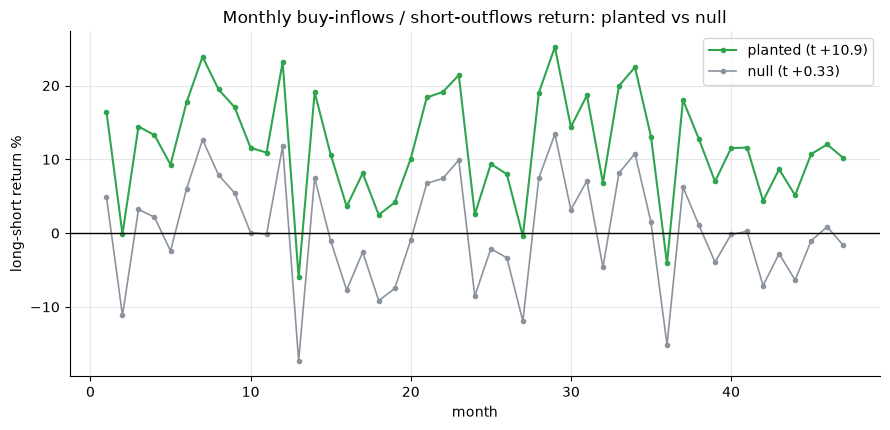

PLANTED mean +11.8%/mo | t +10.88 | placebo p 0.0005 | n 47
NULL    mean +0.4%/mo | t +0.33 | placebo p 0.746


In [2]:
ls = st.long_short_series(PANEL, 0.3); r = st.ls_tstat(ls)
p = st.placebo_pvalue(PANEL, 0.3, n_perm=2000, seed=583)
ls0 = st.long_short_series(NULL, 0.3); r0 = st.ls_tstat(ls0)
p0 = st.placebo_pvalue(NULL, 0.3, n_perm=2000, seed=583)
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(ls.index, ls.values*100, 'o-', c=GREEN, lw=1.5, ms=3, label=f'planted (t {r["t"]:+.1f})')
ax.plot(ls0.index, ls0.values*100, 'o-', c=GREY, lw=1.2, ms=3, label=f'null (t {r0["t"]:+.2f})')
ax.axhline(0, c='k', lw=1); ax.set_xlabel('month'); ax.set_ylabel('long-short return %')
ax.set_title('Monthly buy-inflows / short-outflows return: planted vs null'); ax.legend()
plt.tight_layout(); plt.show()
print(f'PLANTED mean +{r["mean"]*100:.1f}%/mo | t {r["t"]:+.2f} | placebo p {p:.4f} | n {r["n"]}')
print(f'NULL    mean +{r0["mean"]*100:.1f}%/mo | t {r0["t"]:+.2f} | placebo p {p0:.3f}')

> 💡 In plain words: in the planted world H₁ **holds decisively** — spread **+11.8%/mo**, *t* +10.9, placebo *p* 0.0005. In the null world the same engine is **flat** (*t* +0.33, placebo *p* 0.75). The detector is honest; the ceiling is data, not machinery.

### 4b · The protocol-level slope — H₂

Pooled OLS of forward return on the monthly-z-scored TVL-growth signal, with month-clustered standard errors.

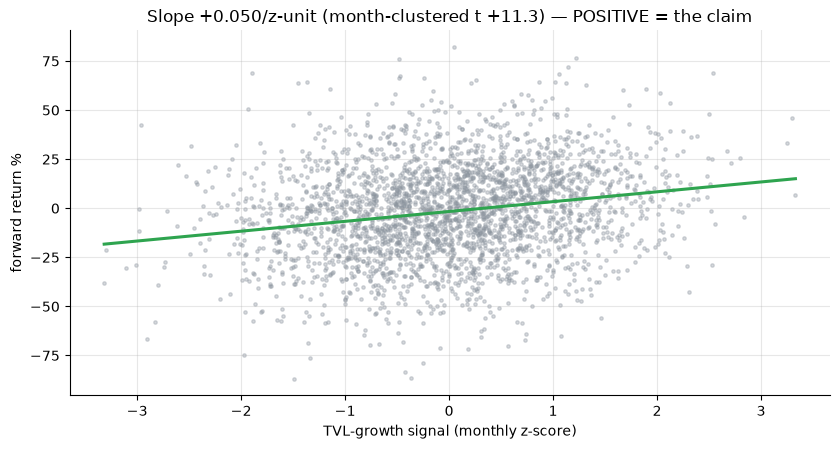

PLANTED slope +0.050, clustered t +11.33, n 2820
NULL    slope +0.000, clustered t +0.03


In [3]:
reg = st.pooled_slope(PANEL); reg0 = st.pooled_slope(NULL)
df = PANEL.copy(); df['z'] = df.groupby('month')['tvl_growth'].transform(
    lambda s: (s-s.mean())/s.std(ddof=1))
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.scatter(df['z'], df['fwd_ret']*100, s=6, color=GREY, alpha=.35)
xs = np.linspace(df['z'].min(), df['z'].max(), 50)
b0 = df['fwd_ret'].mean() - reg['slope']*df['z'].mean()
ax.plot(xs, (reg['slope']*xs + b0)*100, c=GREEN, lw=2.2)
ax.set_xlabel('TVL-growth signal (monthly z-score)'); ax.set_ylabel('forward return %')
ax.set_title(f'Slope {reg["slope"]:+.3f}/z-unit (month-clustered t {reg["slope_t"]:+.1f}) — POSITIVE = the claim')
plt.tight_layout(); plt.show()
print(f'PLANTED slope {reg["slope"]:+.3f}, clustered t {reg["slope_t"]:+.2f}, n {reg["n"]}')
print(f'NULL    slope {reg0["slope"]:+.3f}, clustered t {reg0["slope_t"]:+.2f}')

> 💡 In plain words: H₂ **holds** in the planted world — slope **+0.05** per z-unit (clustered *t* +11.3), and ≈0 (*t* +0.03) at the null. The clustered SE stops within-month cross-sectional correlation from faking the *t*.

### 4c · Robustness — H₃ (basket size × entry lag)

The long-short *t* over a grid of basket fractions and entry lags (planted world).

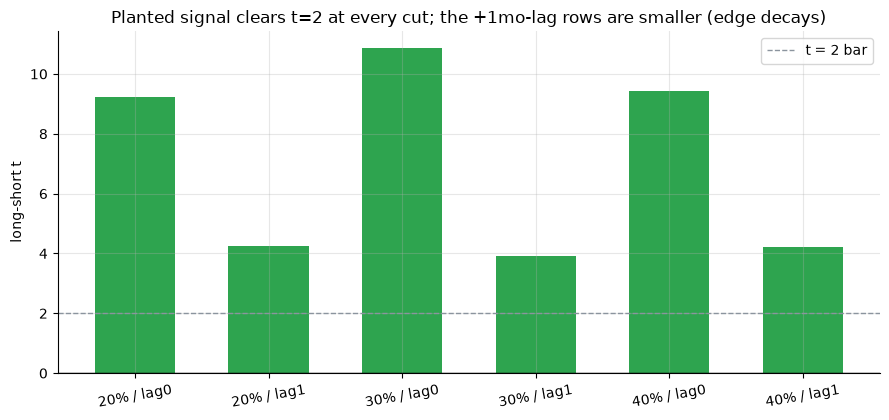

 frac  lag  mean      t  n
  0.2    0 0.133  9.232 47
  0.2    1 0.053  4.240 46
  0.3    0 0.118 10.880 47
  0.3    1 0.044  3.901 46
  0.4    0 0.093  9.421 47
  0.4    1 0.042  4.230 46


In [4]:
grid = st.robustness(PANEL, fracs=(0.2,0.3,0.4), lags=(0,1))
labs = [f"{int(f*100)}% / lag{lg}" for f,lg in zip(grid['frac'], grid['lag'])]
fig, ax = plt.subplots(figsize=(9, 4.3))
cols = [GREEN if t>=2 else AMBER for t in grid['t']]
ax.bar(range(len(grid)), grid['t'], color=cols, width=.6)
ax.set_xticks(range(len(grid))); ax.set_xticklabels(labs, rotation=10)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = 2 bar')
ax.axhline(0, c='k', lw=1); ax.set_ylabel('long-short t')
ax.set_title('Planted signal clears t=2 at every cut; the +1mo-lag rows are smaller (edge decays)')
ax.legend(); plt.tight_layout(); plt.show()
print(grid.round(3).to_string(index=False))

> 💡 In plain words: H₃ **holds** in the planted world — every basket cut clears *t* = 2. The `lag=1` rows are markedly smaller (*t* ~3.9–4.2 vs ~9–11): a one-month-late entry roughly **halves** the mean spread. A fast on-chain flow signal decays fast.

## 5 · The verdict

- **Signal `WEAK`** — the engine banks the planted effect (H₁ *t* +10.9, H₂ slope-*t* +11.3, H₃ survives) and stays flat at the null, but **H₀ fails**: no survivorship-free, point-in-time real tape exists on a free stack, so the claim cannot be certified `REAL` — capped at `WEAK`.
- **Tradability `MIRAGE`** — monthly rebalance × 2 legs + an 800 bps/yr borrow on an **unborrowable** short leg (the tokens gapping to zero); gross +11.8%/mo → net +10.5%/mo even in the planted world.

## 6 · Could you trade it? — costs and the borrow

Charge a one-way cost per leg per monthly rebalance plus a punitive borrow on the short leg (collapsing-TVL tokens).

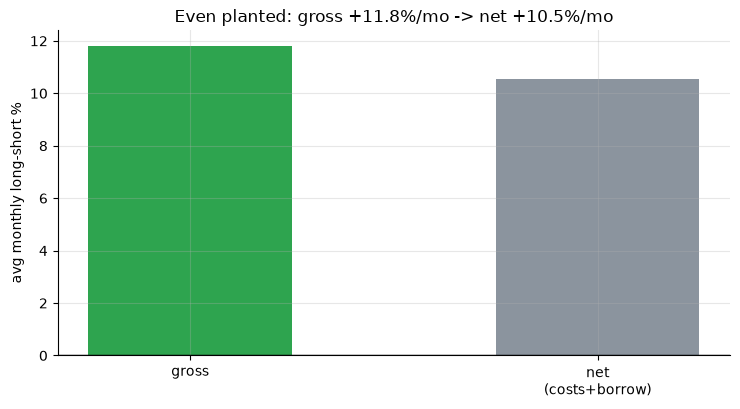

gross +11.8%/mo (142%/yr) -> net +10.5%/mo (127%/yr)
30 bps/leg x 2 legs monthly + 800 bps/yr borrow on the short leg


In [5]:
ls = st.long_short_series(PANEL, 0.3)
nm = st.net_mean(ls, cost_bps=30.0, borrow_ann_bps=800.0)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(['gross', 'net\n(costs+borrow)'], [nm['gross_m']*100, nm['net_m']*100],
       color=[GREEN, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('avg monthly long-short %')
ax.set_title(f'Even planted: gross +{nm["gross_m"]*100:.1f}%/mo -> net +{nm["net_m"]*100:.1f}%/mo')
plt.tight_layout(); plt.show()
print(f'gross +{nm["gross_m"]*100:.1f}%/mo ({nm["gross_ann"]*100:.0f}%/yr) -> '
      f'net +{nm["net_m"]*100:.1f}%/mo ({nm["net_ann"]*100:.0f}%/yr)')
print('30 bps/leg x 2 legs monthly + 800 bps/yr borrow on the short leg')

> 💡 In plain words: even in the *planted* world the costs bite. On a **real** tape the short leg — the rug/exploit tail — is **impossible to borrow** and gaps to zero, so the realisable net is worse than any gross. `MIRAGE`.

## 7 · Going further — the seed-robust synthetic positive control

Is the engine a faithful detector, or does it always print a positive *t*? Sweep the planted `tvl_alpha` from 0 (null) upward and watch the long-short *t* — averaged over 25 seeds so no single lucky seed can fake it (the house rule for synthetic claims).

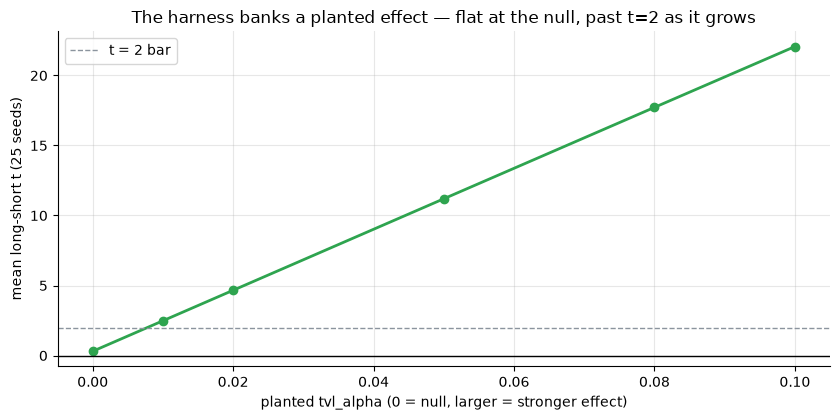

alpha +0.00 -> mean ls-t +0.30
alpha +0.01 -> mean ls-t +2.48
alpha +0.02 -> mean ls-t +4.66
alpha +0.05 -> mean ls-t +11.19
alpha +0.08 -> mean ls-t +17.72
alpha +0.10 -> mean ls-t +22.06


In [6]:
alphas = [0.0, 0.01, 0.02, 0.05, 0.08, 0.10]
ts = [st.synthetic_mean_t(data, tvl_alpha=a, n_seeds=25) for a in alphas]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(alphas, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = 2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted tvl_alpha (0 = null, larger = stronger effect)')
ax.set_ylabel('mean long-short t (25 seeds)')
ax.set_title('The harness banks a planted effect — flat at the null, past t=2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for a, t in zip(alphas, ts): print(f'alpha {a:+.2f} -> mean ls-t {t:+.2f}')

The long-short *t* is ≈ 0 at the null (+0.30 over 25 seeds) and climbs past +2 as the planted effect grows (+11.2 at alpha 0.05). So the engine is a faithful detector — the honest conclusion is about **data availability**, not a broken test. The moment someone assembles a survivorship-free, point-in-time on-chain panel, this machinery is ready to run it. For the desk's price-based crypto folklore see [133 Crypto-Seasonality](../../133-crypto-seasonality/) and [210 Crypto-Trend](../../210-crypto-trend/); for the TradFi flow analogue see [561 ETF-Flow-Momentum](../../561-etf-flow-momentum/).